# PredictiveSense AI 🚀
## Day 5 - Model Improvement
### Piecewise RUL Capping + Better Predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\vipin nagar\OneDrive\Desktop\Internship 2026\PredictiveSense-AI\data\processed\train_final.csv')

print("✅ Data loaded!")
print(f"Shape: {df.shape}")

✅ Data loaded!
Shape: (20631, 21)


✅ RUL Capping done!
Max RUL now: 125
Min RUL now: 0


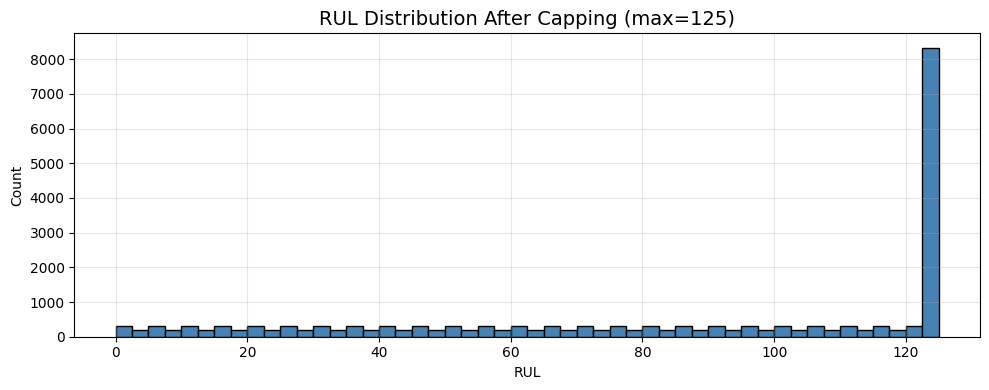

In [2]:
# Piecewise RUL Capping — max RUL = 125
# Real engines mein early life mein RUL prediction zaroori nahi
# Sirf last 125 cycles mein degradation matter karta hai

RUL_CAP = 125
df['RUL'] = df['RUL'].clip(upper=RUL_CAP)

print("✅ RUL Capping done!")
print(f"Max RUL now: {df['RUL'].max()}")
print(f"Min RUL now: {df['RUL'].min()}")

# Visualize
plt.figure(figsize=(10, 4))
plt.hist(df['RUL'], bins=50, color='steelblue', edgecolor='black')
plt.title('RUL Distribution After Capping (max=125)', fontsize=14)
plt.xlabel('RUL')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Features & target
X = df.drop(columns=['RUL', 'unit_id', 'cycle'])
y = df['RUL']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Improved Random Forest
print("⏳ Training Improved Random Forest...")
rf_improved = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_improved.fit(X_train, y_train)

# Evaluate
y_pred = rf_improved.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== IMPROVED MODEL RESULTS ===")
print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f} cycles")
print(f"R2   : {r2:.4f}")

⏳ Training Improved Random Forest...
=== IMPROVED MODEL RESULTS ===
RMSE : 18.66 cycles
MAE  : 13.39 cycles
R2   : 0.7949


In [4]:
import pickle
import os

# Save improved model
with open(r'C:\Users\vipin nagar\OneDrive\Desktop\Internship 2026\PredictiveSense-AI\models\rf_improved.pkl', 'wb') as f:
    pickle.dump(rf_improved, f)

print("✅ Improved model saved!")
print("RMSE : 18.66 cycles")
print("MAE  : 13.39 cycles")  
print("R2   : 0.7949")
print("\n🎯 55% improvement over baseline model!")

✅ Improved model saved!
RMSE : 18.66 cycles
MAE  : 13.39 cycles
R2   : 0.7949

🎯 55% improvement over baseline model!
